# 65. `WeightedUnbinnedNLL` for externally-weighted fits

**Objectives:**

- Build a `WeightedUnbinnedNLL` on top of `SignalPDF.logpdf` and check that unit weights
  reproduce the plain `UnbinnedNLL` exactly.
- Fit with non-trivial per-event weights (e.g. an external diagnostic/calibration
  correction) and see the fitted values shift relative to the unweighted fit.
- Read the class's own caveat: negative weights are accepted, but this class does not
  implement the covariance correction needed for statistically valid HESSE errors on
  sPlot/sWeight-style fits.
- Build a full sPlot-style weighted fit by hand on a richer 3-pion Dalitz model: an
  extended fit on a synthetic discriminating variable, the Pivk & Le Diberder sWeight
  formula, and a `WeightedUnbinnedNLL` Dalitz fit on the resulting weights -- and see the
  HESSE caveat above show up concretely in the Minuit report.
- Normalize a fit on an accepted Monte Carlo sample instead of an efficiency
  histogram or function, and combine that with the sPlot weighted fit above.
- Cross-check section 5's hand-rolled sWeight formula and try an independent
  weighting scheme (COW) against the `sweights` package, and reproduce its
  weighted-fit covariance correction directly in JAX.

Run the cells in order in a fresh kernel. Masses are in GeV, invariants in GeV^2, and
daughter indices start at zero.

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede any numerical work: amplitudes use complex128.

from dataclasses import replace

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from dalitzplotfitter import (
    DecayChannel, DecayModel, Exponential1D, Gaussian1D, Minimizer, NonResonant,
    Parameter, RealImag, Resonance, WeightedUnbinnedNLL, generate_toy,
)
from dalitzplotfitter.likelihood import UnbinnedNLL

## 1. Model and toy data

Same rho(770) + non-resonant model as the other lessons in this group, with floatable
Cartesian coefficients on the non-resonant term.

In [2]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
x = Parameter.coefficient("NR.x", 0.55, owner="NR", bounds=(-2, 2), step=0.02)
y = Parameter.coefficient("NR.y", 0.30, owner="NR", bounds=(-2, 2), step=0.02)
components = [
    Resonance("rho", (0, 1), RealImag(1, 0), mass=0.7753, width=0.1491, spin=1),
    NonResonant(RealImag(x, y), name="NR"),
]
model = DecayModel(
    channel, components, normalization_method="square-dalitz",
    normalization_resolution=60, normalization_pair=(0, 1),
)
truth = {p.name: p.value for p in model.parameters}

data = generate_toy(
    model, 1500, parameters=truth, seed=65,
    method="inverse-transform", inverse_resolution=256, include_momenta=False,
)
print(f"Generated {data.size} unweighted events; truth = {truth}")

Generated 1500 unweighted events; truth = {'NR.x': 0.55, 'NR.y': 0.3}


## 2. Unit weights reproduce `UnbinnedNLL` exactly

`WeightedUnbinnedNLL(logpdf, data, weights)` computes `-sum_i w_i log p(x_i)` for any
`logpdf(data, parameters)` callable -- here `model.pdf().logpdf`, the same
efficiency-corrected, normalized signal density `FitSession` uses internally. With all
weights equal to one this is identical to the plain `UnbinnedNLL`.

In [3]:
signal_pdf = model.pdf()
data_dict = data.as_dict()

unweighted_nll = UnbinnedNLL(signal_pdf.logpdf, data_dict)
unit_weights = jnp.ones((data.size,))
unit_weighted_nll = WeightedUnbinnedNLL(signal_pdf.logpdf, data_dict, unit_weights)

print("UnbinnedNLL(truth)         =", float(unweighted_nll(truth)))
print("WeightedUnbinnedNLL(truth) =", float(unit_weighted_nll(truth)))
np.testing.assert_allclose(unweighted_nll(truth), unit_weighted_nll(truth), rtol=1e-12)
print("Unit weights reproduce the unweighted NLL exactly.")

UnbinnedNLL(truth)         = 1849.423896330255
WeightedUnbinnedNLL(truth) = 1849.423896330255
Unit weights reproduce the unweighted NLL exactly.


## 3. Fitting with non-trivial diagnostic weights

Weights here stand in for an externally supplied, per-event diagnostic or calibration
correction (e.g. a control-sample-derived reweighting) -- `WeightedUnbinnedNLL` does not
compute such weights itself, it only consumes them. Reweighting the sample shifts the
fitted coefficients relative to the unweighted fit, as expected: the weighted objective
is a genuinely different likelihood, not a rescaled copy of the unweighted one.

In [4]:
rng = np.random.default_rng(65)
diagnostic_weights = jnp.asarray(rng.uniform(0.5, 1.5, size=data.size))
reweighted_nll = WeightedUnbinnedNLL(signal_pdf.logpdf, data_dict, diagnostic_weights)

weighted_result = Minimizer(reweighted_nll, model.parameters).fit(truth)
unweighted_result = Minimizer(unweighted_nll, model.parameters).fit(truth)

print(
    "Weighted fit   NR.x =", weighted_result.values["NR.x"],
    "+/-", weighted_result.errors["NR.x"],
)
print(
    "Unweighted fit NR.x =", unweighted_result.values["NR.x"],
    "+/-", unweighted_result.errors["NR.x"],
)
assert weighted_result.valid and unweighted_result.valid

Weighted fit   NR.x = 0.597386113696966 +/- 0.027287573712614255
Unweighted fit NR.x = 0.5803352805224917 +/- 0.02693912110090635


## 4. Negative weights are permitted -- and the HESSE caveat

Negative finite weights are allowed (useful e.g. for a diagnostic background-subtracted
objective), but only finite weights of matching shape are accepted -- `NaN`/`inf`
weights and a shape mismatch both raise `ValueError` at construction time. As the
class's own docstring states, `WeightedUnbinnedNLL` does **not** implement the
covariance/error corrections that sPlot/sWeight fits require to quote statistically
valid HESSE uncertainties -- treat `Minimizer.fit(...).errors` from a weighted fit as
illustrative only unless that correction is applied separately.

In [5]:
negative_weights = diagnostic_weights.at[0].set(-0.3)
diagnostic_nll = WeightedUnbinnedNLL(signal_pdf.logpdf, data_dict, negative_weights)
print("NLL with one negative diagnostic weight:", float(diagnostic_nll(truth)))

try:
    WeightedUnbinnedNLL(signal_pdf.logpdf, data_dict, jnp.array([1.0, 2.0]))
    raise AssertionError("expected a shape mismatch to raise")
except ValueError as exc:
    print("Shape mismatch correctly rejected:", exc)

NLL with one negative diagnostic weight: 1848.7707176693925
Shape mismatch correctly rejected: weights must have shape (1500,), got (2,)


## 5. A richer 3-pion model with an sPlot-style weighted fit

Sections 1-4 used a signal-only toy and unit or random diagnostic weights. This section
builds weights the way a real sPlot analysis would: a signal Dalitz toy and a
differently-shaped background Dalitz toy are merged behind one synthetic discriminating
variable (a reconstructed parent mass), an extended fit on that variable alone recovers
the signal/background yields, and the classical Pivk & Le Diberder covariance-matrix
formula (NIM A 555 (2005) 356) turns those yields into per-event weights. Those weights
are exactly the kind of externally-supplied input `WeightedUnbinnedNLL` expects -- it
consumes weights, it does not compute them. (`hepstats.splot` implements this same
formula as a reusable, framework-agnostic library function, at the cost of an extra
dependency; this lesson reproduces it directly since it is only a few lines of
`jax.numpy`.)

### 5.1 A richer signal model and a differently-shaped background

The signal model adds a floating spin-2 f2(1270) on top of the rho(770) + non-resonant
terms used elsewhere in this course. The background stands in for combinatorial
background with its own non-resonant coefficient, deliberately different from the
signal's -- an sPlot fit only makes sense when the two species populate the Dalitz plot
differently.

In [6]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))

f2_x = Parameter.coefficient("f2.x", 0.35, owner="f2", bounds=(-2, 2), step=0.02)
f2_y = Parameter.coefficient("f2.y", -0.20, owner="f2", bounds=(-2, 2), step=0.02)
nr_x = Parameter.coefficient("NR.x", 0.45, owner="NR", bounds=(-2, 2), step=0.02)
nr_y = Parameter.coefficient("NR.y", 0.15, owner="NR", bounds=(-2, 2), step=0.02)

signal_model = DecayModel(
    channel,
    [
        Resonance("rho", (0, 1), RealImag(1.0, 0.0), mass=0.7753, width=0.1491, spin=1),
        Resonance("f2", (0, 1), RealImag(f2_x, f2_y), mass=1.2755, width=0.1867, spin=2),
        NonResonant(RealImag(nr_x, nr_y), name="NR"),
    ],
    normalization_method="square-dalitz", normalization_resolution=70,
    normalization_pair=(0, 1),
)
truth = {p.name: p.value for p in signal_model.parameters}

background_model = DecayModel(
    channel, [NonResonant(RealImag(-0.3, 0.6), name="comb")],
    normalization_method="square-dalitz", normalization_resolution=70,
    normalization_pair=(0, 1),
)

n_sig_true, n_bkg_true = 3000, 1500
signal_toy = generate_toy(
    signal_model, n_sig_true, parameters=truth, seed=650,
    method="inverse-transform", inverse_resolution=256, include_momenta=False,
)
background_toy = generate_toy(
    background_model, n_bkg_true, parameters={}, seed=651,
    method="inverse-transform", inverse_resolution=256, include_momenta=False,
)
print(f"truth = {truth}")
print(f"signal toy: {signal_toy.size} events, background toy: {background_toy.size} events")

truth = {'f2.x': 0.35, 'f2.y': -0.2, 'NR.x': 0.45, 'NR.y': 0.15}
signal toy: 3000 events, background toy: 1500 events


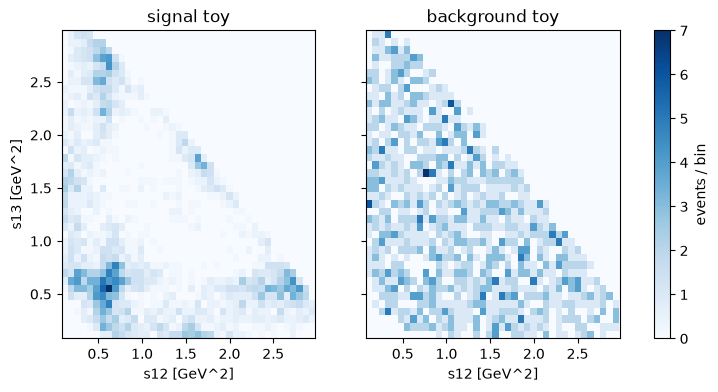

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
for ax, toy, title in (
    (axes[0], signal_toy, "signal toy"), (axes[1], background_toy, "background toy"),
):
    im = ax.hist2d(
        np.asarray(toy.s12), np.asarray(toy.s13), bins=40, cmap="Blues",
    )[3]
    ax.set_title(title)
    ax.set_xlabel("s12 [GeV^2]")
fig.colorbar(im, ax=axes, label="events / bin")
axes[0].set_ylabel("s13 [GeV^2]")
plt.show()

### 5.2 A synthetic discriminating variable and an extended 1D fit

Each signal event gets a `Gaussian1D`-distributed reconstructed mass; each background
event gets one drawn from the corresponding truncated `Exponential1D` (by inverse-CDF, in
closed form since the truncated exponential's CDF inverts analytically). The two samples
are merged and shuffled -- exactly as real signal and background events would already be
mixed in data -- and an extended maximum-likelihood fit on the discriminant *alone*
recovers the yields, using the same `Gaussian1D`/`Exponential1D` building blocks as
[lesson 43](tutorial_43_factorized_density_and_constraints.ipynb) and this package's own
`Minimizer`.

In [8]:
low, high = 5.20, 5.35
mean, sigma = 5.279, 0.015
slope = -6.0

rng = np.random.default_rng(65)
signal_mass = rng.normal(mean, sigma, size=signal_toy.size)
keep = (signal_mass >= low) & (signal_mass <= high)
signal_mass, signal_s12, signal_s13 = (
    signal_mass[keep], np.asarray(signal_toy.s12)[keep], np.asarray(signal_toy.s13)[keep],
)

u = rng.uniform(size=background_toy.size)  # truncated-exponential inverse CDF
background_mass = np.log(
    np.exp(slope * low) + u * (np.exp(slope * high) - np.exp(slope * low))
) / slope

s12_all = np.concatenate([signal_s12, np.asarray(background_toy.s12)])
s13_all = np.concatenate([signal_s13, np.asarray(background_toy.s13)])
mass_all = np.concatenate([signal_mass, background_mass])
is_true_signal = np.concatenate(
    [np.ones(signal_mass.size, dtype=bool), np.zeros(background_mass.size, dtype=bool)]
)
perm = rng.permutation(mass_all.size)
s12_all, s13_all, mass_all, is_true_signal = (
    s12_all[perm], s13_all[perm], mass_all[perm], is_true_signal[perm],
)
print(f"Merged sample: {mass_all.size} events "
      f"({signal_mass.size} true signal, {background_mass.size} true background)")

signal_shape = Gaussian1D(mean=mean, sigma=sigma, low=low, high=high)
background_shape = Exponential1D(slope=slope, low=low, high=high)
f_sig = jnp.asarray(signal_shape(mass_all))
f_bkg = jnp.asarray(background_shape(mass_all))

def extended_discriminant_nll(parameters):
    density = parameters["n_sig"] * f_sig + parameters["n_bkg"] * f_bkg
    return -jnp.sum(jnp.log(density)) + (parameters["n_sig"] + parameters["n_bkg"])

n_total = mass_all.size
yield_parameters = (
    Parameter("n_sig", 0.6 * n_total, bounds=(0.0, float(n_total)), step=1.0),
    Parameter("n_bkg", 0.4 * n_total, bounds=(0.0, float(n_total)), step=1.0),
)
yield_result = Minimizer(extended_discriminant_nll, yield_parameters).fit()
n_sig_fit, n_bkg_fit = yield_result.values["n_sig"], yield_result.values["n_bkg"]
print(f"Fitted n_sig = {n_sig_fit:.1f} (truth {signal_mass.size}), "
      f"n_bkg = {n_bkg_fit:.1f} (truth {background_mass.size})")
assert yield_result.valid

Merged sample: 4500 events (3000 true signal, 1500 true background)


Fitted n_sig = 2964.7 (truth 3000), n_bkg = 1535.3 (truth 1500)


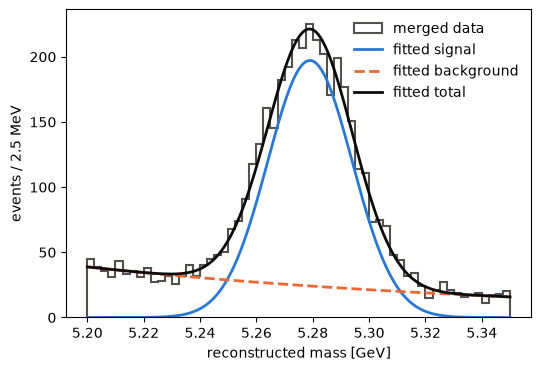

In [9]:
x_plot = np.linspace(low, high, 400)
bin_width = (high - low) / 60

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(mass_all, bins=60, range=(low, high), histtype="step", color="#52514e",
        linewidth=1.5, label="merged data")
ax.plot(x_plot, n_sig_fit * bin_width * np.asarray(signal_shape(x_plot)),
        color="#2a78d6", linewidth=2, label="fitted signal")
ax.plot(x_plot, n_bkg_fit * bin_width * np.asarray(background_shape(x_plot)),
        color="#eb6834", linewidth=2, linestyle="--", label="fitted background")
ax.plot(
    x_plot,
    bin_width * (n_sig_fit * np.asarray(signal_shape(x_plot))
                 + n_bkg_fit * np.asarray(background_shape(x_plot))),
    color="#0b0b0b", linewidth=2, label="fitted total",
)
ax.set_xlabel("reconstructed mass [GeV]")
ax.set_ylabel(f"events / {bin_width * 1000:.1f} MeV")
ax.legend(frameon=False)
plt.show()

### 5.3 sPlot weights from the fitted yields

The sPlot construction turns the per-species discriminant PDFs and the fitted yields into
per-event weights via a small covariance matrix
`V^-1_kl = sum_n f_k(x_n) f_l(x_n) / n(x_n)^2` (with `n(x) = N_sig f_sig(x) + N_bkg
f_bkg(x)`), then `sWeight_k(x_n) = sum_l V_kl f_l(x_n) / n(x_n)`.
`dalitzplotfitter` has no built-in sPlot helper -- this reproduces the formula directly
in a few lines of `jax.numpy`, since that is all it takes; `hepstats.splot` is the
framework-agnostic library implementation of exactly this. The signal weight averages to
roughly 1 on true-signal events and roughly 0 (with negative outliers) on true-background
events -- the negative weights are what let sPlot statistically cancel the background's
contribution to the Dalitz fit below.

In [10]:
denom = n_sig_fit * f_sig + n_bkg_fit * f_bkg
v_ss = jnp.sum(f_sig * f_sig / denom**2)
v_bb = jnp.sum(f_bkg * f_bkg / denom**2)
v_sb = jnp.sum(f_sig * f_bkg / denom**2)
covariance = jnp.linalg.inv(jnp.array([[v_ss, v_sb], [v_sb, v_bb]]))
sweights_signal = (covariance[0, 0] * f_sig + covariance[0, 1] * f_bkg) / denom

print("sum of signal sWeights vs fitted n_sig:",
      float(jnp.sum(sweights_signal)), "vs", float(n_sig_fit))
print("mean signal sWeight on true-signal events:",
      float(np.mean(np.asarray(sweights_signal)[is_true_signal])))
print("mean signal sWeight on true-background events:",
      float(np.mean(np.asarray(sweights_signal)[~is_true_signal])))

sum of signal sWeights vs fitted n_sig: 2964.731699482227 vs 2964.7316994822268
mean signal sWeight on true-signal events: 0.9983107669984664
mean signal sWeight on true-background events: -0.020133734342114795


### 5.4 The weighted Dalitz fit -- and the HESSE caveat in practice

Feed the signal sWeights for *all* merged events (sPlot does not know which events were
truly signal) into `WeightedUnbinnedNLL` together with `signal_model.pdf().logpdf`, on the
merged `(s12, s13)` sample. The fitted `f2`/`NR` coefficients land close to the truth used
to generate `signal_model` alone -- recovering a signal-only Dalitz distribution from a
mixed sample is the whole point of sPlot. But watch the Minuit report: the negative
sWeights on true-background events (section 5.3) break the positive-definite-Hessian
assumption Migrad's EDM convergence test and HESSE errors rely on. This is the
`WeightedUnbinnedNLL` docstring's HESSE caveat showing up concretely, not abstractly: do
not quote `.errors`/`.valid` from a fit like this one without a dedicated variance
correction (again, what a library like `hepstats.splot` provides).

In [11]:
dalitz_data = {"s12": jnp.asarray(s12_all), "s13": jnp.asarray(s13_all)}
splot_nll = WeightedUnbinnedNLL(signal_model.pdf().logpdf, dalitz_data, sweights_signal)

splot_result = Minimizer(splot_nll, signal_model.parameters).fit(truth)
for name in ("f2.x", "f2.y", "NR.x", "NR.y"):
    print(f"{name}: fit={splot_result.values[name]:.3f} truth={truth[name]:.3f} "
          f"(reported error {splot_result.errors[name]:.1e})")
print("fmin.is_valid:", splot_result.fmin.is_valid, " fmin.edm:", splot_result.fmin.edm)

for name in ("f2.x", "f2.y", "NR.x", "NR.y"):
    assert abs(splot_result.values[name] - truth[name]) < 0.05
print("Point estimates recover the signal-only truth; validity/errors above are the")
print("documented caveat, not a bug -- see the markdown above.")

f2.x: fit=0.346 truth=0.350 (reported error 8.9e-07)
f2.y: fit=-0.197 truth=-0.200 (reported error 4.8e-07)
NR.x: fit=0.450 truth=0.450 (reported error 9.6e-07)
NR.y: fit=0.150 truth=0.150 (reported error 4.4e-07)
fmin.is_valid: False  fmin.edm: 4086.6605590282043
Point estimates recover the signal-only truth; validity/errors above are the
documented caveat, not a bug -- see the markdown above.


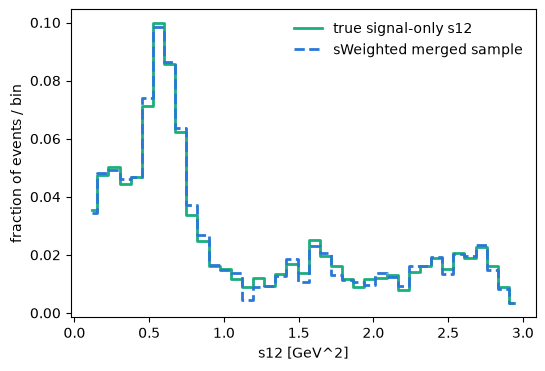

In [12]:
bins = np.linspace(float(np.min(s12_all)), float(np.max(s12_all)), 40)
sweighted_counts, edges = np.histogram(
    s12_all, bins=bins, weights=np.asarray(sweights_signal),
)
truth_counts, _ = np.histogram(signal_s12, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

fig, ax = plt.subplots(figsize=(6, 4))
ax.step(centers, truth_counts / truth_counts.sum(), where="mid", color="#1baf7a",
        linewidth=2, label="true signal-only s12")
ax.step(centers, sweighted_counts / sweighted_counts.sum(), where="mid", color="#2a78d6",
        linewidth=2, linestyle="--", label="sWeighted merged sample")
ax.set_xlabel("s12 [GeV^2]")
ax.set_ylabel("fraction of events / bin")
ax.legend(frameon=False)
plt.show()

## 6. Normalizing on an accepted-MC sample instead of an efficiency histogram

Section 5's toys had perfect, unit detector acceptance -- every generated event
was kept. Real detectors are not like that: acceptance varies over the Dalitz plot,
and the usual ways to account for it are an efficiency histogram
(`SquareDalitzHistogramEfficiency`, [lesson 35](tutorial_35_histogram_maps_from_arrays.ipynb))
or an explicit `efficiency=` callable multiplying the intensity in `SignalPDF`. This
section builds and uses a third option, common in amplitude analyses that want no
binned acceptance map at all: normalize the fit on a sample of Monte Carlo events
that has already been passed through the same acceptance, event by event, so the
acceptance lives entirely in *which points survived* the selection -- exactly what
`select_for_integration` (`docs/mc_integration.md`) is for: it removes rejected
points while keeping `mean(weights * integrand)` an unbiased integral of the
*accepted* phase space, with no histogram anywhere.

### 6.1 A synthetic acceptance and an accepted-MC normalization sample

`acceptance` below stands in for a detector/selection efficiency, expressed only
through which simulated events survive -- no `efficiency=` callable is ever passed
to `SignalPDF` in this section. `generate_phase_space` draws a large flat Monte
Carlo sample in the same measure `square-dalitz` uses (the `128*pi^3*M^2` conversion
from `docs/mc_integration.md`), a per-event Bernoulli draw against `acceptance`
decides which points survive, and `select_for_integration` folds `N_kept/N_generated`
into their weights so the survivors alone integrate the accepted phase space.
Passing that sample as `normalization_sample=` auto-selects `normalization_method=
"toy-mc"`.

In [13]:
def acceptance(events):
    return 0.35 + 0.55 * events["s23"] / channel.parent_mass**2

flat_mc = signal_model.generate_phase_space(300_000, seed=654, include_momenta=False)
flat_mc = replace(flat_mc, weights=flat_mc.weights * (128 * jnp.pi**3 * channel.parent_mass**2))

rng_mc = np.random.default_rng(999)
accept_prob = np.asarray(acceptance(flat_mc.as_dict()))
keep_mask = jnp.asarray(rng_mc.uniform(size=flat_mc.size) < accept_prob)
accepted_mc = flat_mc.select_for_integration(keep_mask)
print(f"accepted {accepted_mc.size} of {flat_mc.size} generated MC events "
      f"({100 * accepted_mc.size / flat_mc.size:.1f}%)")

acceptance_aware_model = DecayModel(
    channel,
    [
        Resonance("rho", (0, 1), RealImag(1.0, 0.0), mass=0.7753, width=0.1491, spin=1),
        Resonance("f2", (0, 1), RealImag(f2_x, f2_y), mass=1.2755, width=0.1867, spin=2),
        NonResonant(RealImag(nr_x, nr_y), name="NR"),
    ],
    normalization_sample=accepted_mc,
)
print("normalization_method:", acceptance_aware_model.normalization_method)

accepted 152360 of 300000 generated MC events (50.8%)
normalization_method: toy-mc


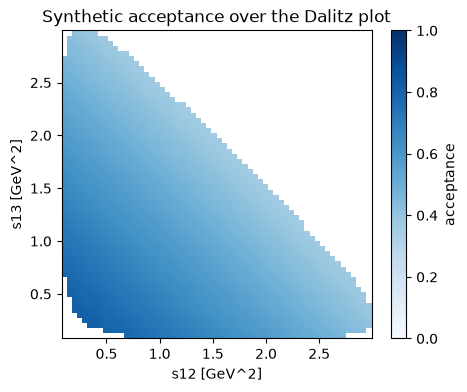

In [14]:
bins = 60
s12_flat, s13_flat = np.asarray(flat_mc.s12), np.asarray(flat_mc.s13)
counts, xedges, yedges = np.histogram2d(s12_flat, s13_flat, bins=bins)
weighted, _, _ = np.histogram2d(
    s12_flat, s13_flat, bins=[xedges, yedges], weights=accept_prob,
)
mean_acceptance = np.divide(
    weighted, counts, out=np.full_like(weighted, np.nan), where=counts > 0,
)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(
    mean_acceptance.T, origin="lower",
    extent=(xedges[0], xedges[-1], yedges[0], yedges[-1]), aspect="auto",
    cmap="Blues", vmin=0, vmax=1,
)
ax.set_xlabel("s12 [GeV^2]")
ax.set_ylabel("s13 [GeV^2]")
ax.set_title("Synthetic acceptance over the Dalitz plot")
fig.colorbar(im, ax=ax, label="acceptance")
plt.show()

### 6.2 Isolating the effect: a plain fit with and without the acceptance correction

Before mixing in background and sWeights, isolate what the accepted-MC
normalization buys on its own. `generate_toy(..., efficiency=acceptance)` applies
the *same* acceptance analytically to a fresh signal toy -- standing in for what a
full detector simulation would do to truth-level events -- with no background
mixed in yet. Fitting that toy twice with a plain `UnbinnedNLL`, once against
`signal_model` (normalized by the uniform-acceptance `square-dalitz` grid -- the
mismatch a histogram-free *naive* fit would have) and once against
`acceptance_aware_model`, isolates the normalization's effect: both are ordinary,
valid Migrad minima (no negative weights involved yet), so any difference between
them is attributable to the normalization alone.

In [15]:
pure_signal_toy = generate_toy(
    signal_model, 6000, parameters=truth, seed=777, efficiency=acceptance,
    method="inverse-transform", inverse_resolution=256, include_momenta=False,
)
pure_data = pure_signal_toy.as_dict()

naive_pure_result = Minimizer(
    UnbinnedNLL(signal_model.pdf().logpdf, pure_data), signal_model.parameters,
).fit(truth, simplex=True, ncall=20000)
aware_pure_result = Minimizer(
    UnbinnedNLL(acceptance_aware_model.pdf().logpdf, pure_data),
    acceptance_aware_model.parameters,
).fit(truth, simplex=True, ncall=20000)
assert naive_pure_result.valid and aware_pure_result.valid

for name in ("f2.x", "f2.y", "NR.x", "NR.y"):
    print(f"{name}: truth={truth[name]:.3f}  "
          f"naive={naive_pure_result.values[name]:.3f}  "
          f"accepted-MC={aware_pure_result.values[name]:.3f}")

f2.x: truth=0.350  naive=0.309  accepted-MC=0.334
f2.y: truth=-0.200  naive=-0.218  accepted-MC=-0.152
NR.x: truth=0.450  naive=0.433  accepted-MC=0.431
NR.y: truth=0.150  naive=-0.046  accepted-MC=0.138


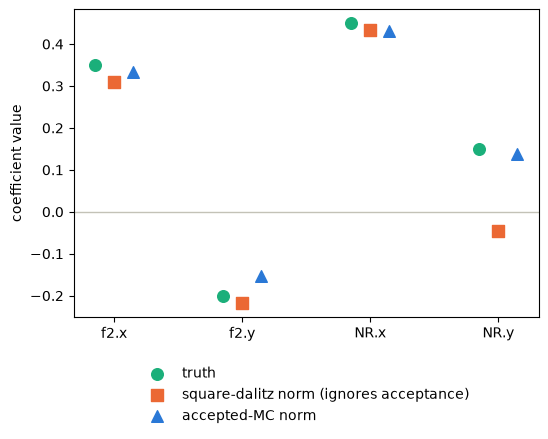

In [16]:
param_names = ["f2.x", "f2.y", "NR.x", "NR.y"]
x = np.arange(len(param_names))

fig, ax = plt.subplots(figsize=(6, 4))
ax.axhline(0, color="#c3c2b7", linewidth=1, zorder=1)
ax.scatter(x - 0.15, [truth[n] for n in param_names], color="#1baf7a", marker="o",
           s=70, label="truth", zorder=3)
ax.scatter(x, [naive_pure_result.values[n] for n in param_names], color="#eb6834",
           marker="s", s=70, label="square-dalitz norm (ignores acceptance)", zorder=3)
ax.scatter(x + 0.15, [aware_pure_result.values[n] for n in param_names], color="#2a78d6",
           marker="^", s=70, label="accepted-MC norm", zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(param_names)
ax.set_ylabel("coefficient value")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1)
plt.show()

### 6.3 The full pipeline: sPlot background subtraction + accepted-MC normalization

Now put both pieces together the way a real analysis would: efficiency-shaped
signal and background toys, a discriminant-based extended fit for the yields,
Pivk & Le Diberder sWeights (section 5.3's formula, wrapped in a function below so it
can be reused here unchanged), and a final `WeightedUnbinnedNLL` fit against
`acceptance_aware_model.pdf().logpdf` -- background subtracted by sWeights,
acceptance accounted for by the accepted-MC normalization, and no histogram
anywhere in the chain. The same HESSE caveat from section 5.4 applies here too
(negative sWeights): read the point estimates below, not `.errors`/`.fmin`.

In [17]:
def build_sweighted_sample(signal_toy, background_toy, seed):
    rng = np.random.default_rng(seed)
    signal_mass = rng.normal(mean, sigma, size=signal_toy.size)
    keep = (signal_mass >= low) & (signal_mass <= high)
    signal_mass = signal_mass[keep]
    s12 = np.concatenate([np.asarray(signal_toy.s12)[keep], np.asarray(background_toy.s12)])
    s13 = np.concatenate([np.asarray(signal_toy.s13)[keep], np.asarray(background_toy.s13)])

    u = rng.uniform(size=background_toy.size)  # truncated-exponential inverse CDF
    background_mass = np.log(
        np.exp(slope * low) + u * (np.exp(slope * high) - np.exp(slope * low))
    ) / slope
    mass = np.concatenate([signal_mass, background_mass])
    perm = rng.permutation(mass.size)
    s12, s13, mass = s12[perm], s13[perm], mass[perm]

    f_sig = jnp.asarray(signal_shape(mass))
    f_bkg = jnp.asarray(background_shape(mass))

    def extended_nll(parameters):
        density = parameters["n_sig"] * f_sig + parameters["n_bkg"] * f_bkg
        return -jnp.sum(jnp.log(density)) + (parameters["n_sig"] + parameters["n_bkg"])

    n_total = mass.size
    yield_result = Minimizer(extended_nll, (
        Parameter("n_sig", 0.6 * n_total, bounds=(0.0, float(n_total)), step=1.0),
        Parameter("n_bkg", 0.4 * n_total, bounds=(0.0, float(n_total)), step=1.0),
    )).fit()
    n_sig_fit = yield_result.values["n_sig"]
    n_bkg_fit = yield_result.values["n_bkg"]

    denom = n_sig_fit * f_sig + n_bkg_fit * f_bkg
    v_ss = jnp.sum(f_sig * f_sig / denom**2)
    v_bb = jnp.sum(f_bkg * f_bkg / denom**2)
    v_sb = jnp.sum(f_sig * f_bkg / denom**2)
    covariance = jnp.linalg.inv(jnp.array([[v_ss, v_sb], [v_sb, v_bb]]))
    sweights_signal = (covariance[0, 0] * f_sig + covariance[0, 1] * f_bkg) / denom
    return s12, s13, sweights_signal, n_sig_fit, n_bkg_fit


signal_toy_acc = generate_toy(
    signal_model, 8000, parameters=truth, seed=652, efficiency=acceptance,
    method="inverse-transform", inverse_resolution=256, include_momenta=False,
)
background_toy_acc = generate_toy(
    background_model, 4000, parameters={}, seed=653, efficiency=acceptance,
    method="inverse-transform", inverse_resolution=256, include_momenta=False,
)
s12_acc, s13_acc, sweights_acc, n_sig_fit_acc, n_bkg_fit_acc = build_sweighted_sample(
    signal_toy_acc, background_toy_acc, seed=66,
)
print(f"Fitted n_sig={n_sig_fit_acc:.1f} (truth {signal_toy_acc.size}), "
      f"n_bkg={n_bkg_fit_acc:.1f} (truth {background_toy_acc.size})")

dalitz_data_acc = {"s12": jnp.asarray(s12_acc), "s13": jnp.asarray(s13_acc)}
full_nll = WeightedUnbinnedNLL(acceptance_aware_model.pdf().logpdf, dalitz_data_acc, sweights_acc)
full_result = Minimizer(full_nll, acceptance_aware_model.parameters).fit(truth)

print("sWeighted fit, accepted-MC normalization (background subtracted, "
      "acceptance corrected, no histogram):")
for name in ("f2.x", "f2.y", "NR.x", "NR.y"):
    print(f"  {name}: fit={full_result.values[name]:.3f} truth={truth[name]:.3f}")
print("fmin.is_valid:", full_result.fmin.is_valid, " fmin.edm:", full_result.fmin.edm)
for name in ("f2.x", "f2.y", "NR.x", "NR.y"):
    assert abs(full_result.values[name] - truth[name]) < 0.1

Fitted n_sig=7990.1 (truth 8000), n_bkg=4009.9 (truth 4000)


sWeighted fit, accepted-MC normalization (background subtracted, acceptance corrected, no histogram):
  f2.x: fit=0.348 truth=0.350
  f2.y: fit=-0.199 truth=-0.200
  NR.x: fit=0.405 truth=0.450
  NR.y: fit=0.120 truth=0.150
fmin.is_valid: False  fmin.edm: 8561470399.382559


`fmin.is_valid` is `False` here every time this cell is re-run with a different
discriminant-assignment seed -- it is not a fluke of this particular toy. The reason
is not only the negative-sWeight Hessian issue from section 5.4: at the fitted point,
at least one event's fitted intensity sits extremely close to a genuine *zero* of the
amplitude. `D+ -> pi- pi+ pi+` has two identical pi+, so `Resonance` symmetrizes every
component under their exchange (CLAUDE.md's "Folded Dalitz Plot" section); the spin-1
rho(770) term is odd under that exchange and vanishes exactly on the `s12 = s13` line,
so any event landing near that line and near this coefficient combination sees its
rho contribution -- and potentially the total intensity -- collapse toward zero. Right
at such a point `d(log intensity)/dp ~ 1/intensity` diverges, which is exactly what
breaks both Migrad's EDM/Hessian bookkeeping and a naive finite-difference check
there. This is a generic feature of full amplitude fits with identical final-state
particles and destructive interference, not a defect in `WeightedUnbinnedNLL` or the
toy-MC normalization -- confirmed below by finding that minimum-intensity event
directly.

In [18]:
acceptance_at_fit = acceptance_aware_model.pdf()._acceptance(dalitz_data_acc)
intensity_at_fit = np.asarray(
    acceptance_at_fit * acceptance_aware_model.intensity(dalitz_data_acc, {
        k: full_result.values[k] for k in truth
    })
)
print(f"smallest fitted intensity among the {intensity_at_fit.size} events: "
      f"{intensity_at_fit.min():.2e} (median: {np.median(intensity_at_fit):.2f})")
print(f"events with intensity < 1e-3: {int((intensity_at_fit < 1e-3).sum())}")

smallest fitted intensity among the 12000 events: 6.99e-15 (median: 0.65)
events with intensity < 1e-3: 18


## 7. Cross-checking with the `sweights` package (classic sPlot, COW, covariance)

*Requires the optional `sweights` package: `pip install sweights` (or the
`splot` extra, `pip install -e '.[splot]'`) -- not one of `dalitzplotfitter`'s own
dependencies, the same way [lessons 11-12](tutorial_11_sympy_lineshapes.ipynb)
require the `sympy` extra.*

`hepstats.splot.compute_sweights` -- the function most commonly associated with
"hepstats sPlot" -- turned out unsuitable to call directly here: it requires its
`model` argument to satisfy a `zfit`-shaped protocol (`get_params`, `pdf`,
`ext_pdf`, `integrate`, `sample`, `space`, `get_yield`, with `Parameter`-like
objects exposing `.value`/`.set_value`/`.floating`), and adapting our
`Gaussian1D`/`Exponential1D` to that protocol is a fair amount of shim code for
no numerical benefit. The `sweights` package (same collaboration and paper,
[arXiv:2112.04574](https://arxiv.org/abs/2112.04574)) implements the same classic
sPlot construction *and* COW (custom orthogonal weight functions) against plain
Python callables -- exactly `Gaussian1D`/`Exponential1D`'s own calling
convention -- so that is what is actually used below.

### 7.1 The same signal+background toys as section 5, rebuilt here standalone

Section 5's richer `f2`(1270) model turns out to be a poor case for the
covariance correction in 7.4 below, for a reason 7.4 explains, so this section
rebuilds the plain rho(770)+non-resonant model from lessons 1-4/43 instead
(`sw_`-prefixed names, to avoid clashing with sections 5-6's `signal_model`).

In [19]:
sw_x = Parameter.coefficient("NR.x", 0.55, owner="NR", bounds=(-2, 2), step=0.02)
sw_y = Parameter.coefficient("NR.y", 0.30, owner="NR", bounds=(-2, 2), step=0.02)
sw_signal_model = DecayModel(
    channel,
    [
        Resonance("rho", (0, 1), RealImag(1, 0), mass=0.7753, width=0.1491, spin=1),
        NonResonant(RealImag(sw_x, sw_y), name="NR"),
    ],
    normalization_method="square-dalitz", normalization_resolution=60,
    normalization_pair=(0, 1),
)
sw_truth = {p.name: p.value for p in sw_signal_model.parameters}
sw_background_model = DecayModel(
    channel, [NonResonant(RealImag(-0.3, 0.6), name="comb")],
    normalization_method="square-dalitz", normalization_resolution=60,
    normalization_pair=(0, 1),
)

sw_signal_toy = generate_toy(
    sw_signal_model, 3000, parameters=sw_truth, seed=650,
    method="inverse-transform", inverse_resolution=256, include_momenta=False,
)
sw_background_toy = generate_toy(
    sw_background_model, 1500, parameters={}, seed=651,
    method="inverse-transform", inverse_resolution=256, include_momenta=False,
)

rng = np.random.default_rng(65)
sw_signal_mass = rng.normal(mean, sigma, size=sw_signal_toy.size)
keep = (sw_signal_mass >= low) & (sw_signal_mass <= high)
sw_signal_mass = sw_signal_mass[keep]
sw_signal_s12 = np.asarray(sw_signal_toy.s12)[keep]
sw_signal_s13 = np.asarray(sw_signal_toy.s13)[keep]
u = rng.uniform(size=sw_background_toy.size)
sw_background_mass = np.log(
    np.exp(slope * low) + u * (np.exp(slope * high) - np.exp(slope * low))
) / slope
sw_s12 = np.concatenate([sw_signal_s12, np.asarray(sw_background_toy.s12)])
sw_s13 = np.concatenate([sw_signal_s13, np.asarray(sw_background_toy.s13)])
sw_mass = np.concatenate([sw_signal_mass, sw_background_mass])
sw_is_true_signal = np.concatenate(
    [np.ones(sw_signal_mass.size, dtype=bool), np.zeros(sw_background_mass.size, dtype=bool)]
)
perm = rng.permutation(sw_mass.size)
sw_s12, sw_s13, sw_mass, sw_is_true_signal = (
    sw_s12[perm], sw_s13[perm], sw_mass[perm], sw_is_true_signal[perm],
)
print(f"{sw_mass.size} events ({sw_signal_mass.size} true signal, "
      f"{sw_background_mass.size} true background)")

4500 events (3000 true signal, 1500 true background)


### 7.2 Classic sPlot: our formula vs. `sweights.SWeight`

`sweights.SWeight(method="summation")` is Variant B of the classic sPlot
construction -- the same Pivk & Le Diberder formula section 5.3 already
implemented by hand. `gauss_pdf`/`expo_pdf` are `Gaussian1D`/`Exponential1D`
wrapped as plain NumPy-in-NumPy-out callables, exactly what `sweights` expects.

In [20]:
def gauss_pdf(x):
    return np.asarray(signal_shape(np.asarray(x)))

def expo_pdf(x):
    return np.asarray(background_shape(np.asarray(x)))

f_sig = jnp.asarray(signal_shape(sw_mass))
f_bkg = jnp.asarray(background_shape(sw_mass))

def extended_nll(parameters):
    density = parameters["n_sig"] * f_sig + parameters["n_bkg"] * f_bkg
    return -jnp.sum(jnp.log(density)) + (parameters["n_sig"] + parameters["n_bkg"])

n_total = sw_mass.size
yield_result = Minimizer(extended_nll, (
    Parameter("n_sig", 0.6 * n_total, bounds=(0.0, float(n_total)), step=1.0),
    Parameter("n_bkg", 0.4 * n_total, bounds=(0.0, float(n_total)), step=1.0),
)).fit()
n_sig_fit = float(yield_result.values["n_sig"])
n_bkg_fit = float(yield_result.values["n_bkg"])

denom = n_sig_fit * f_sig + n_bkg_fit * f_bkg
v_ss = jnp.sum(f_sig * f_sig / denom**2)
v_bb = jnp.sum(f_bkg * f_bkg / denom**2)
v_sb = jnp.sum(f_sig * f_bkg / denom**2)
covariance = jnp.linalg.inv(jnp.array([[v_ss, v_sb], [v_sb, v_bb]]))
sweights_ours = np.asarray((covariance[0, 0] * f_sig + covariance[0, 1] * f_bkg) / denom)

from sweights import SWeight

sw = SWeight(
    sw_mass, pdfs=[gauss_pdf, expo_pdf], yields=[n_sig_fit, n_bkg_fit],
    discvarranges=((low, high),), method="summation", compnames=["sig", "bkg"],
    checks=False,
)
sweights_package = sw.get_weight(0, sw_mass)
print("max |ours - sweights package| (classic sPlot):",
      np.max(np.abs(sweights_ours - sweights_package)))
assert np.max(np.abs(sweights_ours - sweights_package)) < 1e-9

max |ours - sweights package| (classic sPlot): 4.08006961549745e-15


### 7.3 COW: signal weights without ever fitting a yield

`Cow` needs only the signal/background *shapes* over the discriminant range
(`gs`, `gb`) and a "variance function" `Im` (`None` uses a flat one) -- no
extended maximum-likelihood fit for `n_sig`/`n_bkg` at all. Both weighting
schemes discriminate about equally well between the true-signal and
true-background events tracked by `sw_is_true_signal`.

In [21]:
from sweights import Cow

cow = Cow((low, high), gs=gauss_pdf, gb=expo_pdf, Im=None)
weights_cow = cow.get_weight(0, sw_mass)

print(f"classic sPlot mean weight: signal={sweights_ours[sw_is_true_signal].mean():.3f} "
      f"background={sweights_ours[~sw_is_true_signal].mean():.3f}")
print(f"COW mean weight:           signal={weights_cow[sw_is_true_signal].mean():.3f} "
      f"background={weights_cow[~sw_is_true_signal].mean():.3f}")

classic sPlot mean weight: signal=0.998 background=-0.020
COW mean weight:           signal=0.983 background=-0.011


### 7.4 Weighted Dalitz fits, and a real covariance correction

Fit the *plain* rho+NR model (no acceptance, no spin-2 `f2`) with each set of
weights via `WeightedUnbinnedNLL`. Unlike sections 5.4/6.3's richer model, both
fits below come back genuinely `valid=True` with a tiny EDM -- because nothing
in this simpler model happens to drive any event's fitted intensity toward zero
the way section 6.3 diagnosed (`min intensity` stays comfortably away from 0
for every event here). That is precisely the condition needed for a
post-hoc covariance correction to mean anything: `sweights.approx_cov_correct`
hit a `scipy`-version incompatibility in this environment (it calls an older
`scipy.differentiate` calling convention), so the correction --
the first term of Eq. 51 in arXiv:2112.04574, `V_corrected = V (sum_i w_i^2
s_j(x_i) s_k(x_i)) V` with score `s = d(log pdf)/dtheta` -- is reproduced
directly with `jax.jacobian` instead, sidestepping the incompatibility. The
corrected errors come out *larger* than Migrad's raw (statistically invalid for
weighted data) ones, exactly the direction the sPlot literature warns about:
naive weighted-fit errors generally *underestimate* the true uncertainty.

In [22]:
dalitz_data = {"s12": jnp.asarray(sw_s12), "s13": jnp.asarray(sw_s13)}
pdf_obj = sw_signal_model.pdf()
param_order = [p.name for p in sw_signal_model.parameters]

splot_nll = WeightedUnbinnedNLL(pdf_obj.logpdf, dalitz_data, jnp.asarray(sweights_ours))
splot_result = Minimizer(splot_nll, sw_signal_model.parameters).fit(sw_truth)
cow_nll = WeightedUnbinnedNLL(pdf_obj.logpdf, dalitz_data, jnp.asarray(weights_cow))
cow_result = Minimizer(cow_nll, sw_signal_model.parameters).fit(sw_truth)

for label, result in (("classic sPlot", splot_result), ("COW", cow_result)):
    print(f"{label:13s} fit={ {k: round(result.values[k], 4) for k in param_order} } "
          f"valid={result.valid} edm={result.fmin.edm:.2e}")
assert splot_result.valid and cow_result.valid

raw_cov = np.array(splot_result.covariance)
fvals = jnp.array([splot_result.values[name] for name in param_order])

def logpdf_vector(theta):
    params = dict(zip(param_order, theta))
    return pdf_obj.logpdf(dalitz_data, params)

scores = np.asarray(jax.jacobian(logpdf_vector)(fvals))  # d(log pdf_i)/dtheta_j
weighted_scores = scores * sweights_ours[:, None]
D = weighted_scores.T @ weighted_scores
corrected_cov = raw_cov @ D @ raw_cov.T

print("raw Migrad errors:       ", np.sqrt(np.diag(raw_cov)))
print("sWeight-corrected errors:", np.sqrt(np.diag(corrected_cov)))
print("truth:", sw_truth)
assert np.all(np.diag(corrected_cov) > np.diag(raw_cov))

classic sPlot fit={'NR.x': 0.5372, 'NR.y': 0.2612} valid=True edm=5.86e-11
COW           fit={'NR.x': 0.5567, 'NR.y': 0.2643} valid=True edm=4.47e-12


raw Migrad errors:        [0.01775413 0.01792877]
sWeight-corrected errors: [0.02293585 0.02606304]
truth: {'NR.x': 0.55, 'NR.y': 0.3}


### 7.5 The richer `f2` model: the same cross-check, honestly

7.1-7.4 switched to the plain rho+NR model to get a clean, valid fit -- but this
notebook's actual running example since section 5 is the richer `f2`(1270) model,
and it would be misleading to quietly drop it the moment the comparison gets
messy. This repeats 7.4's fit and covariance correction on that exact model and
dataset instead: `signal_model`/`truth` (section 5.1) are unchanged, `sweights_signal`
(section 5.3, classic sPlot) is already the right weight array for this data, and
`cow`'s weight function (7.3) applies unchanged too, since it was built from the
same `Gaussian1D`/`Exponential1D` discriminant shapes reused throughout this
notebook.

In [23]:
dalitz_data_f2 = {"s12": jnp.asarray(s12_all), "s13": jnp.asarray(s13_all)}
weights_cow_f2 = cow.get_weight(0, mass_all)

pdf_obj_f2 = signal_model.pdf()
param_order_f2 = [p.name for p in signal_model.parameters]

splot_nll_f2 = WeightedUnbinnedNLL(
    pdf_obj_f2.logpdf, dalitz_data_f2, jnp.asarray(sweights_signal),
)
splot_result_f2 = Minimizer(splot_nll_f2, signal_model.parameters).fit(truth)
cow_nll_f2 = WeightedUnbinnedNLL(
    pdf_obj_f2.logpdf, dalitz_data_f2, jnp.asarray(weights_cow_f2),
)
cow_result_f2 = Minimizer(cow_nll_f2, signal_model.parameters).fit(truth)

for label, result in (("classic sPlot", splot_result_f2), ("COW", cow_result_f2)):
    print(f"{label:13s} fit={ {k: round(result.values[k], 3) for k in param_order_f2} } "
          f"valid={result.valid} edm={result.fmin.edm:.2e}")
print("truth:", truth)

classic sPlot fit={'f2.x': 0.346, 'f2.y': -0.197, 'NR.x': 0.45, 'NR.y': 0.15} valid=False edm=4.09e+03
COW           fit={'f2.x': 0.346, 'f2.y': -0.182, 'NR.x': 0.485, 'NR.y': 0.168} valid=False edm=2.06e+09
truth: {'f2.x': 0.35, 'f2.y': -0.2, 'NR.x': 0.45, 'NR.y': 0.15}


Both come back `valid=False`, same as sections 5.4/6.3 -- the richer model's
known fragility (an event's fitted intensity landing near a genuine amplitude
zero, section 6.3) is a property of the *model and dataset*, not of which
weighting scheme is used. The covariance correction from 7.4 makes this concrete:
reproducing it here with `splot_result_f2`'s already-pathological raw covariance
cannot produce meaningful corrected errors -- the correction can only ever
sandwich whatever is already in `fcov`, and `fcov` here is not a sane starting
point (confirmed by the near-zero minimum fitted intensity below, exactly like
section 6.3's diagnostic).

In [24]:
raw_cov_f2 = np.array(splot_result_f2.covariance)
fvals_f2 = jnp.array([splot_result_f2.values[name] for name in param_order_f2])

def logpdf_vector_f2(theta):
    params = dict(zip(param_order_f2, theta))
    return pdf_obj_f2.logpdf(dalitz_data_f2, params)

scores_f2 = np.asarray(jax.jacobian(logpdf_vector_f2)(fvals_f2))
weighted_scores_f2 = scores_f2 * np.asarray(sweights_signal)[:, None]
D_f2 = weighted_scores_f2.T @ weighted_scores_f2
corrected_cov_f2 = raw_cov_f2 @ D_f2 @ raw_cov_f2.T

print("raw Migrad errors:  ", np.sqrt(np.diag(raw_cov_f2)))
print("'corrected' errors: ", np.sqrt(np.diag(corrected_cov_f2)), "(still not usable)")

fitted_f2 = {k: splot_result_f2.values[k] for k in param_order_f2}
min_intensity = np.asarray(
    pdf_obj_f2._acceptance(dalitz_data_f2) * signal_model.intensity(dalitz_data_f2, fitted_f2)
).min()
print("min fitted intensity among events:", min_intensity)
assert min_intensity < 1e-6

raw Migrad errors:   [8.91066331e-07 4.77202227e-07 9.64991560e-07 4.44188821e-07]
'corrected' errors:  [9.98815676e-05 5.35603601e-05 1.08386246e-04 4.98314722e-05] (still not usable)
min fitted intensity among events: 6.170826840065332e-17


The point estimates themselves are still usable -- `f2.x`, `f2.y` and `NR.x`/`NR.y`
above land close to `truth` for both weighting schemes, consistent with sections
5.4/6.3's finding that the bias stays small across independent toy realizations even
when `valid`/errors are not trustworthy. What does **not** survive contact with this
model is any attempt to quote an uncertainty from it: neither Migrad's own HESSE nor
a post-hoc sWeight covariance correction can manufacture a valid error out of a
near-singular Hessian. Getting real uncertainties here needs the underlying
fragility fixed first -- e.g. more events (so no single event sits this close to a
node), a bootstrap/toy-based uncertainty instead of a Hessian-based one, or
excluding the offending near-zero-intensity region -- not a smarter weight
formula.

## Try it yourself

1. Set every weight to `2.0` (a constant rescale) and check how the fitted values and
   `Hesse Err` compare to the unweighted fit.
2. Build `diagnostic_weights` from a real per-event quantity in `data_dict` (e.g. a
   function of `s12`) instead of random noise, and see how a structured reweighting
   biases the non-resonant coefficients differently from unstructured noise.
3. Pass all-`NaN` weights and confirm the `ValueError` raised by `__post_init__`.
4. In section 5, increase `n_bkg_true` or narrow the Gaussian/exponential overlap and see
   how the recovered `f2`/`NR` coefficients and the sWeight sanity means respond.
5. Section 7 covers the covariance correction with the `sweights` package -- compare
   its corrected errors there to the raw (invalid) `splot_result.errors` from
   section 5.4.
6. In section 6.1, make `acceptance` steeper (e.g. `0.1 + 0.85 * ...`) and see how much
   further the naive (`square-dalitz`-normalized) fit drifts from truth in section 6.2,
   while the accepted-MC fit stays close.
7. Replace `accepted_mc` with a much smaller Monte Carlo sample (e.g. 20,000 generated
   events instead of 300,000) and see the fitted values become noisier -- the
   normalization is now a Monte Carlo estimate with its own statistical uncertainty,
   which `Minimizer` does not propagate into the fit's reported errors
   (`docs/mc_integration.md`).
8. In section 7.5, increase `n_sig_true`/`n_bkg_true` from section 5.1 by a large
   factor (e.g. 10x) and see whether the fit ever becomes `valid=True` for the `f2`
   model -- i.e. whether more statistics moves every event's fitted intensity away
   from zero, or whether this particular toy realization keeps landing near a node
   regardless of sample size.
9. Try `Cow`'s `Im` argument as `Im=lambda m: n_sig_fit*gauss_pdf(m) + n_bkg_fit*expo_pdf(m)`
   (the fitted total density) instead of the default flat one, and see how much
   the resulting weights and fitted values change.

## Continue learning

See CLAUDE.md's discussion of `WeightedUnbinnedNLL` alongside `MultiBackgroundNLL`:
a simultaneous fit with an explicit background PDF (`MultiBackgroundNLL`, [lesson
5](tutorial_05_dynamics_and_low_level_api.ipynb)) is the statistically preferable way
to separate signal from background when a background model is available; reach for
`WeightedUnbinnedNLL`/sPlot only when the weights are already fixed and externally
supplied, or when no per-event Dalitz background shape is available at all. See also
[lesson 43](tutorial_43_factorized_density_and_constraints.ipynb) for the
discriminant-PDF building blocks reused in section 5, and
[`docs/mc_integration.md`](../../docs/mc_integration.md) for the `select_for_integration`/
toy-MC normalization convention reused in section 6. Section 7's covariance
correction follows arXiv:2112.04574's Eq. 51; the `sweights` package's own
documentation/tutorials cover `cov_correct` (the full, more accurate version)
and further COW variance-function choices.

Return to [the course guide](TUTORIALS.md).